#**Data Wrangling | Airbnb en la Patagonia Argentina**

### Limpieza, transformación, validación y enriquecimiento de datos con Python

**Proyecto de portfolio · Data Analytics / Data Wrangling**

**Preparado por: Fedra Vaz**

> Objetivo: transformar cuatro fuentes de datos heterogéneas en un dataset consistente y analíticamente utilizable, documentando las decisiones de calidad de datos y transformación.

## Contexto y objetivo

Los datos originales presentan problemas habituales en proyectos reales: información distribuida en varios archivos, registros duplicados, valores faltantes, variables almacenadas con formatos inconsistentes y múltiples atributos contenidos en una misma columna.

El objetivo es construir un **pipeline reproducible de preparación de datos** que permita identificar estos problemas, aplicar criterios de limpieza y dejar la información lista para análisis exploratorio y modelado posterior.


### Objetivos del proyecto

- Integrar cuatro fuentes de datos en una única estructura analítica.
- Evaluar la calidad inicial del dataset y detectar inconsistencias.
- Identificar y tratar duplicados utilizando criterios de negocio y no únicamente coincidencias exactas.
- Gestionar valores faltantes y comparar estrategias de imputación.
- Estandarizar formatos y tipos de datos.
- Transformar información no estructurada en nuevas variables analíticas.
- Evaluar la distribución de precios y detectar valores atípicos.
- Enriquecer el dataset con información obtenida mediante una API externa.
- Validar el dataset final y documentar recomendaciones para mejorar la captura de datos.


### Stack tecnológico

**Python · Pandas · NumPy · SciPy · Matplotlib · Seaborn · Plotly · Requests · REST API · Google Colab**


## Resumen del proyecto

**Dataset inicial:** 1.080 registros · 12 variables  
**Dataset depurado:** 1.007 registros · 26 variables  
**Registros redundantes eliminados:** 73  
**Fuentes integradas:** 4 datasets regionales  
**Enriquecimiento:** API externa de amanecer/atardecer  

### Pipeline
`Integración` → `Perfilado` → `Duplicados` → `Faltantes` → `Estandarización` → `Feature Engineering` → `Outliers` → `API` → `Análisis`

### Decisiones técnicas destacadas
- Detección de duplicados mediante reglas multivariables, evitando eliminar observaciones válidas solo por compartir identificadores.
- Comparación de imputación por media global frente a mediana segmentada por localidad y categoría.
- Conservación de variables originales y creación de columnas limpias para mantener trazabilidad.
- Comparación de discretización por igual ancho e igual frecuencia.
- Extracción de variables desde texto semiestructurado y enriquecimiento mediante una API REST.

## 1. Integración y exploración inicial de los datos


### 1.1 Carga de las cuatro fuentes y validación de estructura


In [ ]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import pearsonr
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio # Added this import
pd.options.display.float_format = '{:.2f}'.format
pd.options.mode.chained_assignment = None



In [ ]:
#importamos los archivos con datasets
df1=pd.read_csv("/content/Neuquen.csv", delimiter= ",", parse_dates=["check_in", "check_out"])
df2=pd.read_csv("/content/Rio_Negro.csv", delimiter=",", parse_dates=["check_in", "check_out"])
df3=pd.read_csv("/content/San_Martin_de_los_Andes.csv", delimiter=",", parse_dates=["check_in", "check_out"])
df4=pd.read_csv("/content/Tierra_del_Fuego.csv", delimiter=",", parse_dates=["check_in", "check_out"])

### 1.2 Incorporación de la variable geográfica `place`


In [ ]:
#Creamos la columna en cada archivo antes de unir los 4 archivos.
df1["place"]="Neuquen"
df2["place"]="Rio Negro"
df3["place"]="San Martin de los Andes"
df4["place"]="Tierra del Fuego"

### 1.3 Consolidación de las cuatro fuentes en un único DataFrame


In [ ]:
#Usamos reset_index(drop=True) para reordenar los índices y nombramos el dataframe.
patag_arg=pd.concat([df1,df2,df3,df4],join= "outer").reset_index(drop=True)

### 1.4 Perfil inicial del dataset consolidado


In [ ]:
#Nuevo dataframe con la suma de filas de los 4 datasets(270*4=1080)
patag_arg.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_alojamiento    1080 non-null   float64       
 1   name              1080 non-null   object        
 2   category          1080 non-null   object        
 3   rating            891 non-null    object        
 4   city              1074 non-null   object        
 5   latitude          1080 non-null   float64       
 6   longitude         1080 non-null   float64       
 7   characteristics   1080 non-null   object        
 8   check_in          1080 non-null   datetime64[ns]
 9   check_out         1080 non-null   datetime64[ns]
 10  price_discounted  208 non-null    object        
 11  price_original    1080 non-null   object        
 12  place             1080 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(8)
memory usage: 109.8+ KB


## 2. Calidad de datos: detección y tratamiento de duplicados


### 2.1 Duplicados exactos


In [ ]:
#Conteo de filas enteras en el dataset que son copias de otra fila
patag_arg.duplicated().sum()

np.int64(33)

**Hallazgo.** Se identificaron 33 copias exactas: 4 en la fuente de Río Negro y 29 en Tierra del Fuego. Estos registros se consideran redundantes derivados del proceso de integración de datos y se eliminan conservando la primera ocurrencia.


In [ ]:
#Eliminamos las filas duplicadas en todas sus columnas, conservando el primer registro y creamos un nuevo dataset
patag_arg_sindupl=patag_arg.drop_duplicates(keep="first")

In [ ]:
#Confirmamos que el dataset quedó con 1047 filas (1080-33)
patag_arg_sindupl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1047 entries, 0 to 1079
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_alojamiento    1047 non-null   float64       
 1   name              1047 non-null   object        
 2   category          1047 non-null   object        
 3   rating            864 non-null    object        
 4   city              1041 non-null   object        
 5   latitude          1047 non-null   float64       
 6   longitude         1047 non-null   float64       
 7   characteristics   1047 non-null   object        
 8   check_in          1047 non-null   datetime64[ns]
 9   check_out         1047 non-null   datetime64[ns]
 10  price_discounted  200 non-null    object        
 11  price_original    1047 non-null   object        
 12  place             1047 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(8)
memory usage: 114.5+ KB


### 2.2 Análisis de unicidad por variable

Una vez eliminados los duplicados exactos, se analiza la repetición de valores por columna. Este control permite detectar variables que deberían funcionar como identificadores y posibles inconsistencias que requieren una revisión más profunda.


In [ ]:
#Teniendo en cuenta que son 1047 filas en total,
#parecen razonables: place y category (con 4 y 3 valores posibles respectivamente).
#llaman la atención:id_alojamiento y name.
for col in patag_arg_sindupl.columns:
    cant_duplicados_por_columna = patag_arg_sindupl[col].duplicated().sum()
    print(col,':', cant_duplicados_por_columna, 'valores repetidos')


id_alojamiento : 58 valores repetidos
name : 43 valores repetidos
category : 1044 valores repetidos
rating : 581 valores repetidos
city : 987 valores repetidos
latitude : 87 valores repetidos
longitude : 63 valores repetidos
characteristics : 266 valores repetidos
check_in : 939 valores repetidos
check_out : 936 valores repetidos
price_discounted : 952 valores repetidos
price_original : 872 valores repetidos
place : 1043 valores repetidos


### 2.3 Validación de duplicados potenciales mediante reglas de comparación


In [ ]:
# Si consultamos solamente los id_alojamiento:hay 58 copias de id_alojamiento
patag_arg_sindupl["id_alojamiento"].duplicated().sum()

np.int64(58)

**Hallazgo.** La variable `id_alojamiento` presenta más repeticiones que `name`. Esto indica que una coincidencia de ID no puede tratarse automáticamente como un duplicado: algunos registros podrían corresponder al mismo alojamiento con descripciones diferentes o a una asignación inconsistente del identificador. Por ese motivo, la decisión de eliminación se toma comparando múltiples atributos.


In [ ]:
#Se observa además, que hay muchas filas donde solamente no coincide place que implicaría que los alojamientos están en más de uno de los archivos originales
patag_arg_sindupl.loc[patag_arg_sindupl["name"].duplicated(keep=False)].sort_values(by="name")

,id_alojamiento,name,category,rating,city,latitude,longitude,characteristics,check_in,check_out,price_discounted,price_original,place
464,47975732.00,"""La Posadita"" Casa de Montaña, Miralejos",entire_home,"5,0 (3)",San Martin de los Andes,-40.16,-71.28,"['5 camas', '3 dormitorios', '2 baños', '1 cam...",2023-07-01,2023-07-06,NaN,$250 USD,Rio Negro
605,47975732.00,"""La Posadita"" Casa de Montaña, Miralejos",entire_home,"5,0 (3)",San Martin de los Andes,-40.16,-71.28,"['5 camas', '3 dormitorios', '2 baños', '1 cam...",2023-07-01,2023-07-06,NaN,$250 USD,San Martin de los Andes
430,46318875.00,A LOS PIES DEL ARROYO,entire_home,"4,96 (23)",San Martin de los Andes,-40.14,-71.28,"['1 cama', '1 dormitorio', '1 baño', '1 cama q...",2023-07-01,2023-07-06,NaN,$70 USD,Rio Negro
697,46318875.00,A LOS PIES DEL ARROYO,entire_home,"4,96 (23)",San Martin de los Andes,-40.14,-71.28,"['1 cama', '1 dormitorio', '1 baño', '1 cama q...",2023-07-01,2023-07-06,NaN,$70 USD,San Martin de los Andes
456,557919185259864000.00,"Alojamiento ideal, en un lugar ideal.",entire_home,"4,89 (28)",San Martin de los Andes,-40.16,-71.36,"['3 camas', '1 dormitorio', '1 baño', '1 cama ...",2023-08-05,2023-08-10,NaN,$90 USD,Rio Negro
...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,32564507.00,"Tranquilo, pleno centro, con parrilla",entire_home,"4,91 (98)",San Martin de los Andes,-40.16,-71.34,"['2 camas', '1 dormitorio', '1 baño', 'Wifi', ...",2023-07-29,2023-08-03,NaN,$90 USD,Rio Negro
730,36942457.00,Un Vistón Tiny House a 10 min del Centro,entire_home,"4,89 (37)",San Martin de los Andes,-40.12,-71.29,"['2 camas', '2 dormitorios', '1 baño', '1 cama...",2023-07-11,2023-07-16,NaN,$82 USD,San Martin de los Andes
275,36942457.00,Un Vistón Tiny House a 10 min del Centro,entire_home,"4,89 (37)",San Martin de los Andes,-40.12,-71.29,"['2 camas', '2 dormitorios', '1 baño', '1 cama...",2023-07-11,2023-07-16,NaN,$82 USD,Rio Negro
442,797077259992478976.00,Vista al Lago en el Bosque - Hab Compartida,shared_room,"5,0 (8)",San Carlos de Bariloche,-41.13,-71.37,"['1 cama', '1 dormitorio', '1 baño compartido'...",2023-07-11,2023-07-18,NaN,$21 USD,Rio Negro


Para profundizar el diagnóstico se evalúan distintas combinaciones de columnas. `characteristics` se excluye de algunas reglas de comparación porque contiene texto semiestructurado y pequeñas variaciones de escritura que pueden ocultar registros equivalentes.


El análisis multivariable muestra alojamientos presentes en más de una fuente geográfica. En estos casos se comparan atributos como ciudad, coordenadas, fechas y precios antes de decidir qué registro conservar.


In [ ]:
#Teniendo en cuenta lo anterior, buscamos duplicados para todas las columnas, excepto, para place y characteristics.
patag_arg_sindupl.duplicated(subset=['id_alojamiento','name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original']).sum()

np.int64(19)

In [ ]:
#Extraemos esos casos e investigamos a que provincia realmente pertenece ese alojamiento, considerando city, latitude y longitud.
patag_arg_sindupl.loc[patag_arg_sindupl.duplicated(subset=['id_alojamiento','name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original'], keep=False)].sort_values(by="id_alojamiento")

,id_alojamiento,name,category,rating,city,latitude,longitude,characteristics,check_in,check_out,price_discounted,price_original,place
569,1913711.00,Casa de montaña en el centro,entire_home,"4,7 (194)",San Martín de los Andes,-40.15,-71.35,"['5 camas', '3 dormitorios', '2 baños', '1 cam...",2023-09-25,2023-10-01,NaN,$75 USD,San Martin de los Andes
465,1913711.00,Casa de montaña en el centro,entire_home,"4,7 (194)",San Martín de los Andes,-40.15,-71.35,"['5 camas', '3 dormitorios', '1 cama doble', '...",2023-09-25,2023-10-01,NaN,$75 USD,Rio Negro
491,5684334.00,Gardeners Delight Studio La Casita Barrio Chap...,entire_home,"4,94 (109)",San Martín de los Andes,-40.14,-71.28,"['2 camas', '1 dormitorio', '1 baño', '2 camas...",2023-07-01,2023-07-06,NaN,$49 USD,Rio Negro
722,5684334.00,Gardeners Delight Studio La Casita Barrio Chap...,entire_home,"4,94 (109)",San Martín de los Andes,-40.14,-71.28,"['2 camas', '1 dormitorio', '1 baño', '2 camas...",2023-07-01,2023-07-06,NaN,$49 USD,San Martin de los Andes
607,14373763.00,Depto Malbec Céntrico c/parrilla y pileta,entire_home,"4,76 (135)",San Martin de los Andes,-40.15,-71.34,"['1 cama', '1 dormitorio', '1 baño', '1 cama d...",2023-07-10,2023-07-17,NaN,$59 USD,San Martin de los Andes
437,14373763.00,Depto Malbec Céntrico c/parrilla y pileta,entire_home,"4,76 (135)",San Martin de los Andes,-40.15,-71.34,"['1 cama', '1 dormitorio', '1 baño', '1 cama d...",2023-07-10,2023-07-17,NaN,$59 USD,Rio Negro
696,23005609.00,"El Refugio Miralejos, cabaña en la montaña",entire_home,"4,9 (62)",San Martin de los Andes,-40.16,-71.28,"['4 camas', '1 dormitorio', '1 baño', '1 cama ...",2023-07-01,2023-07-06,NaN,$60 USD,San Martin de los Andes
401,23005609.00,"El Refugio Miralejos, cabaña en la montaña",entire_home,"4,9 (62)",San Martin de los Andes,-40.16,-71.28,"['4 camas', '1 dormitorio', '1 cama doble', '3...",2023-07-01,2023-07-06,NaN,$60 USD,Rio Negro
543,27782581.00,Depto Soñado en San Martín de los Andes (centro),entire_home,"4,96 (108)",San Martin de los Andes,-40.15,-71.35,"['2 camas', 'Monoambiente', '1 baño', 'Wifi', ...",2023-07-01,2023-07-06,$62 USD,$85 USD,San Martin de los Andes
425,27782581.00,Depto Soñado en San Martín de los Andes (centro),entire_home,"4,96 (108)",San Martin de los Andes,-40.15,-71.35,"['2 camas', 'Monoambiente', '1 baño', 'Wifi', ...",2023-07-01,2023-07-06,$62 USD,$85 USD,Rio Negro


In [ ]:
#Creamos una variable para analizar cuales son los lugares donde se ofrecen los mismos alojamientos
en_dos_place=patag_arg_sindupl.loc[patag_arg_sindupl.duplicated(subset=['id_alojamiento','name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original'], keep=False)].sort_values(by="id_alojamiento")


In [ ]:
#En San Martín y Rio Negro, se ofrecen los mismos alojamientos con mismo id_alojamiento
en_dos_place.value_counts("place")

,count
place,
Rio Negro,20
San Martin de los Andes,18


In [ ]:
#Usamos keep="last" para eliminar Rio Negro, ya que están ubicados en la ciudad de San Martín de los Andes (todos, excepto uno que es en Rio Negro y está duplicado como Rio Negro).
# Ese duplicado ubicado en Rio Negro tiene id_alojamiento=53729814.00
#Al eliminar los duplicados, creamos el nuevo subset: patag_arg_sindupl2
patag_arg_sindupl2=patag_arg_sindupl.drop_duplicates(subset=['id_alojamiento','name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original'], keep="last")

In [ ]:
#El nuevo dataset (patag_arg_sindupl2) tiene correctamente 19 registros menos que el dataset anterior (patag_arg_sindupl con 1047 registros)
patag_arg_sindupl2.shape


(1028, 13)

### Casos con identificadores diferentes pero atributos equivalentes

Se detectan publicaciones cuyos IDs difieren parcialmente, pero que coinciden en la mayoría de los atributos relevantes. Estos casos se consideran duplicados potenciales y se revisan mediante una regla compuesta que excluye `place`, `characteristics` e `id_alojamiento`.


In [ ]:
#Al saber que hay alojamientos que se ofrecen en dos localidades con igual id, buscamos si existen otros alojamientos con distinto id_alojamiento registrados en más de una localidad(con diferente place)
en_dos_place2=patag_arg_sindupl2.loc[patag_arg_sindupl2.duplicated(subset=['name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original'], keep=False)].sort_values(by="id_alojamiento")


In [ ]:
#Si bien en estos casos, el id_alojamiento no coincide totalmente, los primeros dígitos de los id son los mismos.
en_dos_place2.sort_values(by="name")

,id_alojamiento,name,category,rating,city,latitude,longitude,characteristics,check_in,check_out,price_discounted,price_original,place
456,557919185259864000.00,"Alojamiento ideal, en un lugar ideal.",entire_home,"4,89 (28)",San Martin de los Andes,-40.16,-71.36,"['3 camas', '1 dormitorio', '1 baño', '1 cama ...",2023-08-05,2023-08-10,NaN,$90 USD,Rio Negro
580,558000000000000000.00,"Alojamiento ideal, en un lugar ideal.",entire_home,"4,89 (28)",San Martin de los Andes,-40.16,-71.36,"['3 camas', '1 dormitorio', '1 baño', '1 cama ...",2023-08-05,2023-08-10,NaN,$90 USD,San Martin de los Andes
724,788000000000000000.00,Apacible y tranquila cabaña entre árboles,entire_home,NaN,San Martin de los Andes,-40.15,-71.32,"['3 camas', '2 dormitorios', '1 ,5 baños', '1 ...",2023-07-01,2023-07-08,$64 USD,$72 USD,San Martin de los Andes
499,788261489321291008.00,Apacible y tranquila cabaña entre árboles,entire_home,NaN,San Martin de los Andes,-40.15,-71.32,"['3 camas', '2 dormitorios', '1 ,5 baños', '1 ...",2023-07-01,2023-07-08,$64 USD,$72 USD,Rio Negro
409,640943103810696960.00,Cabaña Las Piedritas,entire_home,"5,0 (12)",San Martin de los Andes,-40.12,-71.32,"['5 camas', '2 dormitorios', '1 ,5 baños', '1 ...",2023-07-01,2023-07-06,NaN,$140 USD,Rio Negro
629,641000000000000000.00,Cabaña Las Piedritas,entire_home,"5,0 (12)",San Martin de los Andes,-40.12,-71.32,"['5 camas', '2 dormitorios', '1 ,5 baños', '1 ...",2023-07-01,2023-07-06,NaN,$140 USD,San Martin de los Andes
422,617274793784738944.00,Cabaña Los Robles vista Bosque 4 personas Relax,entire_home,"4,94 (32)",San Martin de los Andes,-40.15,-71.34,"['3 camas', '2 dormitorios', '1 baño', '1 cama...",2023-07-01,2023-07-06,$87 USD,$115 USD,Rio Negro
558,617000000000000000.00,Cabaña Los Robles vista Bosque 4 personas Relax,entire_home,"4,94 (32)",San Martin de los Andes,-40.15,-71.34,"['3 camas', '2 dormitorios', '1 baño', '1 cama...",2023-07-01,2023-07-06,$87 USD,$115 USD,San Martin de los Andes
666,577000000000000000.00,Cabaña de MONTAÑA con excelente vista.,entire_home,"4,91 (11)",NaN,-40.14,-71.27,"['2 camas', '2 dormitorios', '1 baño', '2 cama...",2023-07-24,2023-07-29,NaN,$73 USD,San Martin de los Andes
374,577367191901515008.00,Cabaña de MONTAÑA con excelente vista.,entire_home,"4,91 (11)",NaN,-40.14,-71.27,"['2 camas', '2 dormitorios', '1 baño', '2 cama...",2023-07-24,2023-07-29,NaN,$73 USD,Rio Negro


In [ ]:
#Calculamos la cantidad de esos alojamientos registrados tanto en Rio Negro como en S.M.de los Andes y que tienen diferentes id_alojamiento
patag_arg_sindupl2.duplicated(subset=['name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original']).sum()


np.int64(21)

In [ ]:
patag_arg_sindupl3=patag_arg_sindupl2.drop_duplicates(subset=['name',
 'category',
 'rating',
 'city',
 'latitude',
 'longitude',
 'check_in',
 'check_out',
 'price_discounted',
 'price_original'], keep="last")

In [ ]:
#Confirmamos que el nuevo dataset tiene la cantidad correcta de filas (1007=1028-21)
patag_arg_sindupl3.shape

(1007, 13)

### Registros repetidos que se conservan

No toda repetición representa un error. Se conservan casos en los que existen diferencias relevantes —por ejemplo, fecha, precio, cantidad de camas, descripción o ubicación— porque pueden representar publicaciones distintas, unidades similares dentro de un mismo complejo o cambios del mismo alojamiento a lo largo del tiempo.


In [ ]:
#Esta es la consulta que nos dan duplicados que decidimos no eliminar.
#Si sólo consideramos los duplicados en id_alojamiento, categoría, ciudad, check in, check out y place:

patag_arg_sindupl3.duplicated(subset=['id_alojamiento',
 'category','city',
 'check_in',
 'check_out',
 "place"]).sum()

np.int64(13)

### Resultado del tratamiento de duplicados

El proceso combina coincidencia exacta y reglas multivariables. En total se eliminan **73 registros** considerados redundantes, reduciendo el dataset de **1.080 a 1.007 observaciones**. Los casos ambiguos se conservan para evitar pérdida de información.


In [ ]:
patag_arg.shape

(1080, 13)

In [ ]:
patag_arg_sindupl3.shape

(1007, 13)

## 3. Valores faltantes, limpieza y estandarización


### 3.1 Perfil de valores faltantes por variable


In [ ]:
patag_arg_sindupl3.isnull().mean()*100

,0
id_alojamiento,0.00
name,0.00
category,0.00
rating,17.68
city,0.50
latitude,0.00
longitude,0.00
characteristics,0.00
check_in,0.00
check_out,0.00


### 3.2 Evaluación de las variables con mayor proporción de faltantes


In [ ]:
patag_arg_sindupl3.isnull().sum().sort_values(ascending=False)

,0
price_discounted,815
rating,178
city,5
category,0
id_alojamiento,0
name,0
latitude,0
characteristics,0
longitude,0
check_in,0


### 3.3 Normalización y conversión de `rating` a formato numérico


In [ ]:
patag_arg_sindupl3["rating"].unique()

array(['4,71 (165)', '4,93 (14)', '4,62 (47)', '4,97 (32)', '4,83 (122)',
       '4,56 (94)', '4,91 (33)', '4,95 (19)', '4,25 (4)', '4,86 (56)',
       '4,77 (13)', '5,0 (63)', '4,92 (12)', '5,0 (18)', '4,85 (26)',
       '4,76 (26)', '5,0 (4)', '4,5 (8)', '5,0 (11)', '4,63 (8)',
       '4,8 (25)', '4,68 (22)', '4,75 (4)', '5,0 (3)', '4,96 (23)',
       '5,0 (6)', '4,95 (41)', '5,0 (17)', nan, '5,0 (57)', '4,83 (30)',
       '4,6 (5)', '4,92 (92)', '4,72 (25)', '4,9 (10)', '4,67 (9)',
       '4,84 (85)', '5,0 (7)', '4,79 (43)', '4,91 (69)', '3,33 (3)',
       '4,75 (106)', '4,87 (70)', '5,0 (5)', '4,44 (9)', '4,88 (89)',
       '4,6 (10)', '5,0 (10)', '4,91 (11)', '4,67 (3)', '4,86 (22)',
       '4,88 (25)', '4,9 (67)', '4,33 (6)', '4,86 (35)', '4,94 (16)',
       '4,2 (5)', '4,73 (15)', '4,9 (64)', '4,89 (19)', '5,0 (14)',
       '4,87 (115)', '4,5 (4)', '4,43 (35)', '4,71 (21)', '3,67 (3)',
       '3,0 (3)', '4,92 (25)', '4,73 (11)', '4,5 (17)', '4,83 (6)',
       '5,0 (8)', '5,0 (15

In [ ]:
#En primer lugar, debemos quitar el número entre paréntesis con la cantidad de opiniones.
#Creamos una nueva columna con los datos transformados llamada: rating_clean.
#Debido al formato poco uniforme de los datos, debimos usar expresiones regulares para la extracción del número de rating; antes, nos aseguramos de que son strings.
patag_arg_sindupl3["rating_clean"]=patag_arg_sindupl3["rating"].astype(str).str.extract(r'^(\d+[\.,]?\d*)')[0]

In [ ]:
#Luego reemplazamos la coma por el punto usando regex=False para evitar que se interpreten símbolos como expresiones regulares.
patag_arg_sindupl3["rating_clean"]= patag_arg_sindupl3["rating_clean"].str.replace(",", ".", regex=False)

In [ ]:
#Para completar el punto 3.3., pasamos los valores de rating_clean a formato float64; usamos errors="coerce" por si se encuentran valores como cadenas de texto, etc.
patag_arg_sindupl3['rating_clean'] = pd.to_numeric(patag_arg_sindupl3['rating_clean'], errors='coerce')

### 3.4 Imputación de `rating`: comparación entre media y mediana


In [ ]:
#Creamos una nueva columna(rating_clean_2) para utilizarla en la comparación con la mediana.
patag_arg_sindupl3['rating_clean_2'] = patag_arg_sindupl3['rating_clean']

In [ ]:
#Sustituímos los faltantes por la media
patag_arg_sindupl3["rating_clean"]=patag_arg_sindupl3["rating_clean"].fillna(patag_arg_sindupl3["rating_clean"].mean())

In [ ]:
#Creamos una columna llamada "mediana" para calcularla utilizando la agrupación por localidad(place) y por tipo de alojamiento(category)
patag_arg_sindupl3["mediana"] = patag_arg_sindupl3.groupby(["place", "category"])["rating_clean_2"].transform('median')


In [ ]:
#Creamos la columna "rating_clean_2" donde sustituímos los faltantes por la mediana
patag_arg_sindupl3["rating_clean_2"]=patag_arg_sindupl3["rating_clean_2"].fillna(patag_arg_sindupl3["mediana"])

Globalmente, en grandes números la media no parece tener diferencias significativas con respecto a la mediana calculada, considerando la agrupación por place y category.  Donde se presentan las diferencias más visibles es:

*   en "entire home" que por los outliers correspondientes a opiniones con menor puntaje, al calcular el promedio, hace que el cálculo de la media sea más conservador que la mediana.
*   en Neuquen, donde los valores más cercanos a la realidad (con el cáculo de la mediana agrupado por place y category) se presentan menores en "share room" y "private room" con respecto al promedio calculado en rating_clean.




### Comparación visual de las estrategias de imputación


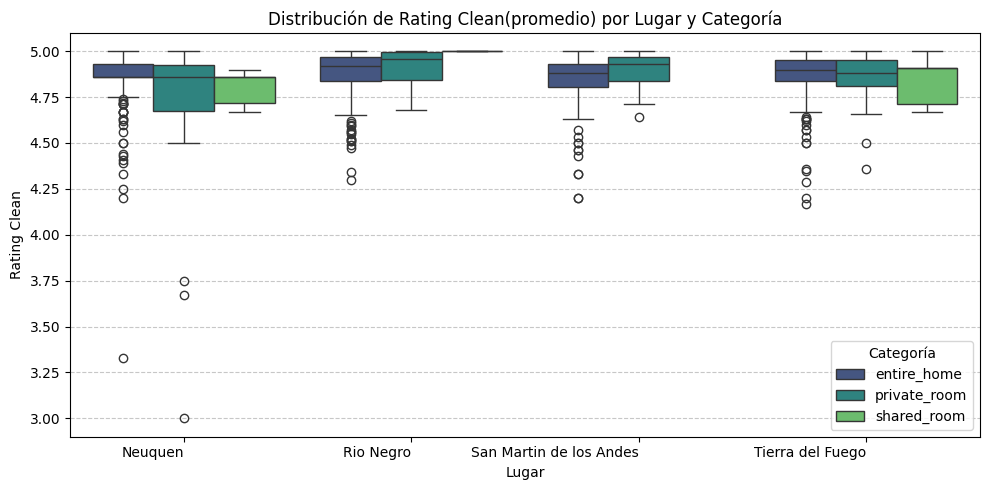

In [ ]:
#Gráfico 1
plt.figure(figsize=(10, 5))
sns.boxplot(data=patag_arg_sindupl3, x='place', y='rating_clean', hue='category', palette='viridis')
plt.title('Distribución de Rating Clean(promedio) por Lugar y Categoría')
plt.xlabel('Lugar')
plt.ylabel('Rating Clean')
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

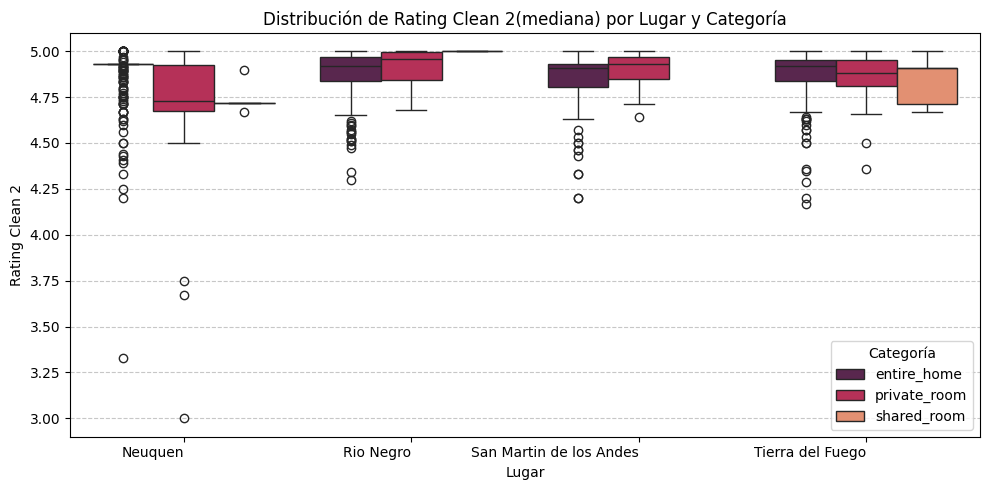

In [ ]:
###Gráfico 2
plt.figure(figsize=(10, 5))
sns.boxplot(data=patag_arg_sindupl3, x='place', y='rating_clean_2', hue='category', palette='rocket')
plt.title('Distribución de Rating Clean 2(mediana) por Lugar y Categoría')
plt.xlabel('Lugar')
plt.ylabel('Rating Clean 2')
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

### 3.5 Ingeniería de variable: `best_reviews`


In [ ]:
patag_arg_sindupl3["best_reviews"]=np.where(patag_arg_sindupl3["rating_clean"]==5.0, True, False)

### 3.6 Proporción de publicaciones con calificación máxima


In [ ]:
patag_arg_sindupl3["best_reviews"].value_counts(normalize=True)*100

,proportion
best_reviews,
False,84.51
True,15.49


### 3.7 Limpieza y conversión de `price_original`


In [ ]:
# Para eso, en primer lugar, observamos su formato actual:
patag_arg_sindupl3["price_original"].unique()

array(['$23\xa0USD', '$18\xa0USD', '$22\xa0USD', '$49\xa0USD',
       '$47\xa0USD', '$29\xa0USD', '$28\xa0USD', '$27\xa0USD',
       '$19\xa0USD', '$45\xa0USD', '$35\xa0USD', '$63\xa0USD',
       '$44\xa0USD', '$42\xa0USD', '$41\xa0USD', '$40\xa0USD',
       '$32\xa0USD', '$51\xa0USD', '$12\xa0USD', '$24\xa0USD',
       '$98\xa0USD', '$30\xa0USD', '$50\xa0USD', '$60\xa0USD',
       '$31\xa0USD', '$79\xa0USD', '$114\xa0USD', '$77\xa0USD',
       '$39\xa0USD', '$26\xa0USD', '$156\xa0USD', '$48\xa0USD',
       '$119\xa0USD', '$34\xa0USD', '$88\xa0USD', '$85\xa0USD',
       '$97\xa0USD', '$90\xa0USD', '$36\xa0USD', '$25\xa0USD',
       '$70\xa0USD', '$20\xa0USD', '$72\xa0USD', '$80\xa0USD',
       '$57\xa0USD', '$55\xa0USD', '$13\xa0USD', '$59\xa0USD',
       '$99\xa0USD', '$33\xa0USD', '$68\xa0USD', '$73\xa0USD',
       '$100\xa0USD', '$87\xa0USD', '$150\xa0USD', '$104\xa0USD',
       '$91\xa0USD', '$74\xa0USD', '$75\xa0USD', '$67\xa0USD',
       '$9\xa0USD', '$52\xa0USD', '$71\xa0USD', '

In [ ]:
#Extraemos solamente el valor para pasarlo a dato numérico; debido a su formato más uniforme, pudimos usar una forma más sencilla que para rating.
#Para mayor claridad en nuestro trabajo, creamos la columna price_original_clean con los datos transformados.
patag_arg_sindupl3["price_original_clean"]=patag_arg_sindupl3["price_original"].str[1:-4]

In [ ]:
# Transformamos los valores a formato int64, .
patag_arg_sindupl3["price_original_clean"]=pd.to_numeric(patag_arg_sindupl3["price_original_clean"], errors="coerce")

### 3.8 Ingeniería de variable: identificación de publicaciones con descuento


La ingeniería de variables (Feature Engineering) consiste en crear, transformar o reorganizar variables a partir de los datos existentes para que sean más útiles para el análisis o para un modelo.

In [ ]:
patag_arg_sindupl3["discounted"]=np.where(patag_arg_sindupl3["price_discounted"].notnull(), True, False)

### 3.9 Tratamiento de faltantes en `price_discounted`


In [ ]:
#Primero, creamos la columna price_discounted_clean para trabajar más ordenadamente sin pisar los datos originales y extraemos la parte de los datos necesaria
patag_arg_sindupl3["price_discounted_clean"]=patag_arg_sindupl3["price_discounted"].astype(str).str.extract(r'(\d+)')[0]

In [ ]:
#Sustituímos los faltantes:
patag_arg_sindupl3["price_discounted_clean"] = patag_arg_sindupl3["price_discounted_clean"].fillna(patag_arg_sindupl3["price_original_clean"])

In [ ]:
#Confirmamos que no haya más datos faltantes en toda la columna del dataset.
patag_arg_sindupl3["price_discounted_clean"].isnull().sum()

np.int64(0)

### 3.10 Conversión final de precios a formato numérico


In [ ]:
patag_arg_sindupl3["price_discounted_clean"]=pd.to_numeric(patag_arg_sindupl3["price_discounted_clean"], errors="coerce")

## 4. Análisis exploratorio de precios


### 4.1 Volumen de publicaciones con descuento


In [ ]:
#Según la columna "discounted", solamente hay 192 alquileres con descuento.
patag_arg_sindupl3["discounted"].sum()

np.int64(192)

### 4.2 Extremos de la distribución: precio mínimo y máximo


In [ ]:
# El alquiler más caro (max=699) y el más barato(min=9), presentados con info():
patag_arg_sindupl3.describe()

,id_alojamiento,latitude,longitude,check_in,check_out,rating_clean,rating_clean_2,mediana,price_original_clean,price_discounted_clean
count,1007.00,1007.00,1007.00,1007,1007,1007.00,1007.00,1007.00,1007.00,1007.00
mean,370508756544736768.00,-43.52,-69.71,2023-07-20 22:51:21.628599808,2023-07-26 05:01:43.674279936,4.86,4.87,4.91,84.06,80.77
min,446831.00,-54.84,-71.69,2023-07-01 00:00:00,2023-07-06 00:00:00,3.00,3.00,4.72,9.00,9.00
25%,34828588.50,-41.17,-71.35,2023-07-01 00:00:00,2023-07-06 00:00:00,4.84,4.83,4.91,45.00,42.00
50%,53972553.00,-40.16,-68.36,2023-07-02 00:00:00,2023-07-08 00:00:00,4.88,4.93,4.92,65.00,62.00
75%,788000000000000000.00,-38.96,-68.10,2023-07-31 12:00:00,2023-08-06 00:00:00,4.94,4.94,4.93,95.00,90.00
max,918988836999320960.00,-38.87,-62.92,2024-05-01 00:00:00,2024-05-06 00:00:00,5.00,5.00,5.00,699.00,699.00
std,390914886801544704.00,6.35,1.64,NaN,NaN,0.16,0.16,0.03,72.01,70.53


###**SANITY CHECK:Este es un ejemplo de la aplicación de este concepto cuando evaluamos la coherencia interna y externa de los datos.  En este caso, los precios mínimos perfectamente pueden corresponder a alojamientos de bajo costo para personas que van a trabajar a Neuquen (precio mín) que es un centro comercial y de negocios, donde van personas con empleos de toda gama de salarios.  Se diferencia claramente de Bariloche(precio max) que es un destino turístico internacional que ofrece lugares muy lujosos con atracciones de alto nivel como el esquí y los lagos.**
En el caso del histograma de precios por lugar, los datos también se presentan muy razonables donde tanto Rio Negro como San Martín de los Andes, incluyen los mayores precios con lugares turísticos como Bariloche y la ciudad de San Martín de los Andes; aunque Villa La Angostura pertenece a la Provinca de Neuquen, observamos que se incluye en Rio Negro (suponemos que podría deberse a  su ubicación mucho más cercana a la ciudad de San Carlos de Bariloche que pertenece a la provincia de Rio Negro) y por lo tanto, debe tenerse en cuenta que no está afectando los precios de Neuquen en el dataset(ver confirmación a continuación).  Por otra parte, los precios de Tierra del Fuego, se encuentran en el medio porque Ushuaia es un destino turístico pero no alcanza el nivel de los primeros.
Si observamos el nivel de rating de cada localidad, tampoco llama la atención que Rio Negro y San Martín de los Andes acumulen la mayor cantidad de opiniones de best_reviews y los outliers de precios.


In [ ]:
#Extracción de registros de Villa La Angostura
villa_la_angostura=patag_arg_sindupl3.loc[patag_arg_sindupl3["city"].str.contains("Villa La Angostura|Villa Angostura", case=False, na=False)]

In [ ]:
#Confirmación de que los registros de Villa La Angostura se incluyen como provincia de Rio Negro
villa_la_angostura.value_counts("place")

,count
place,
Rio Negro,24


In [ ]:
#Consultamos a que corresponden esos valores tan extremos:
patag_arg_sindupl3.loc[(patag_arg_sindupl3["price_discounted_clean"]==9) | (patag_arg_sindupl3["price_discounted_clean"]==699)]

,id_alojamiento,name,category,rating,city,latitude,longitude,characteristics,check_in,check_out,price_discounted,price_original,place,rating_clean,rating_clean_2,mediana,best_reviews,price_original_clean,discounted,price_discounted_clean
118,13998536.00,Habitación privada,private_room,"4,73 (15)",Neuquén,-38.95,-68.07,"['1 cama', '1 dormitorio', '1 baño', 'Wifi']",2023-07-01,2023-07-06,NaN,$9 USD,Neuquen,4.73,4.73,4.73,False,9,False,9
143,13803835.00,Habitación privada en departamento compartido,private_room,"3,0 (3)",Neuquén,-38.95,-68.07,"['1 cama', '1 dormitorio']",2023-07-01,2023-07-06,NaN,$9 USD,Neuquen,3.00,3.00,4.73,False,9,False,9
152,22929455.00,Departamento barrio San Pablo,private_room,"4,5 (17)",Cipolletti,-38.94,-67.98,"['1 cama', '2 dormitorios', '1 baño compartido...",2023-07-01,2023-07-06,NaN,$9 USD,Neuquen,4.50,4.50,4.73,False,9,False,9
288,644276838771394944.00,"Nueva Casa Moderna: Golf, Polo, Cerca de Esquí...",entire_home,"5,0 (25)",San Carlos de Bariloche,-41.17,-71.39,"['12 camas', '4 dormitorios', '5,5 baños', '2 ...",2023-09-20,2023-09-25,NaN,$699 USD,Rio Negro,5.00,5.00,4.92,True,699,False,699


### 4.3 Distribución de precios

Se utilizan visualizaciones complementarias para evaluar concentración, dispersión y diferencias por categoría y localidad.


In [ ]:
# Primer gráfico.(gráfico interactivo que no se aprecia en GitHub)
fig_prices=px.histogram(patag_arg_sindupl3["price_discounted_clean"] )
fig_prices.update_layout(title_text="Distribución de los precios", xaxis_title="Precio con descuento", yaxis_title="Cantidad")
fig_prices.show()


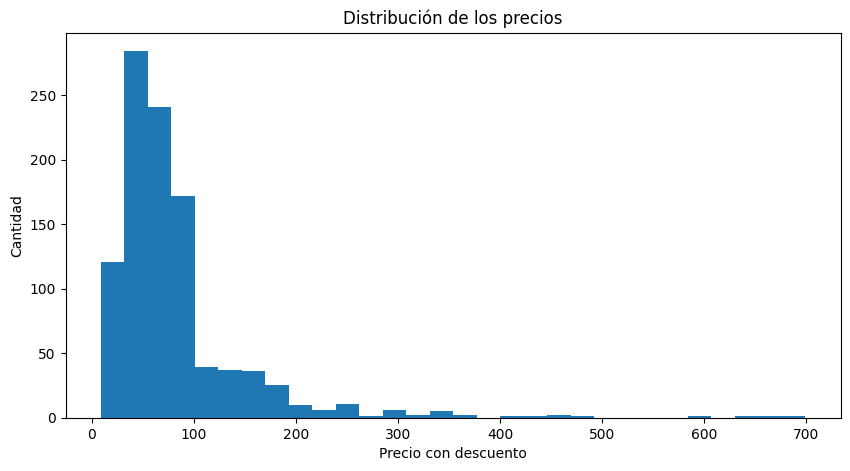

In [ ]:
#Gráfico interactivo transformado a imagen para presentar en GitHub

plt.figure(figsize=(10, 5))

plt.hist(
    patag_arg_sindupl3["price_discounted_clean"].dropna(),
    bins=30
)

plt.title("Distribución de los precios")
plt.xlabel("Precio con descuento")
plt.ylabel("Cantidad")
plt.show()


#### 4.3.1 Distribución por categoría de alojamiento


In [ ]:
# Para el segundo gráfico necesitamos un subset por cada categoría:
categ_entire_home=patag_arg_sindupl3.loc[patag_arg_sindupl3["category"]=="entire_home"]
categ_private_room=patag_arg_sindupl3.loc[patag_arg_sindupl3["category"]=="private_room"]
categ_shared_room=patag_arg_sindupl3.loc[patag_arg_sindupl3["category"]=="shared_room"]


In [ ]:
#2do. gráfico - Precios por categoría (gráfico interactivo que no se aprecia en GitHub)
fig=go.Figure()
fig.add_trace(go.Histogram(histfunc="count", y=categ_entire_home["price_discounted_clean"].to_list(), x=categ_entire_home["price_discounted_clean"].to_list(), name="entire_home"))
fig.add_trace(go.Histogram(histfunc="count", y=categ_private_room["price_discounted_clean"].to_list(), x=categ_private_room["price_discounted_clean"].to_list(), name="private_room"))
fig.add_trace(go.Histogram(histfunc="count", y=categ_shared_room["price_discounted_clean"].to_list(), x=categ_shared_room["price_discounted_clean"].to_list(), name="shared_room"))
fig.update_layout(xaxis_title="Precio con descuento", yaxis_title="Cantidad", title_text="Precios de cada categoría")
fig.show()

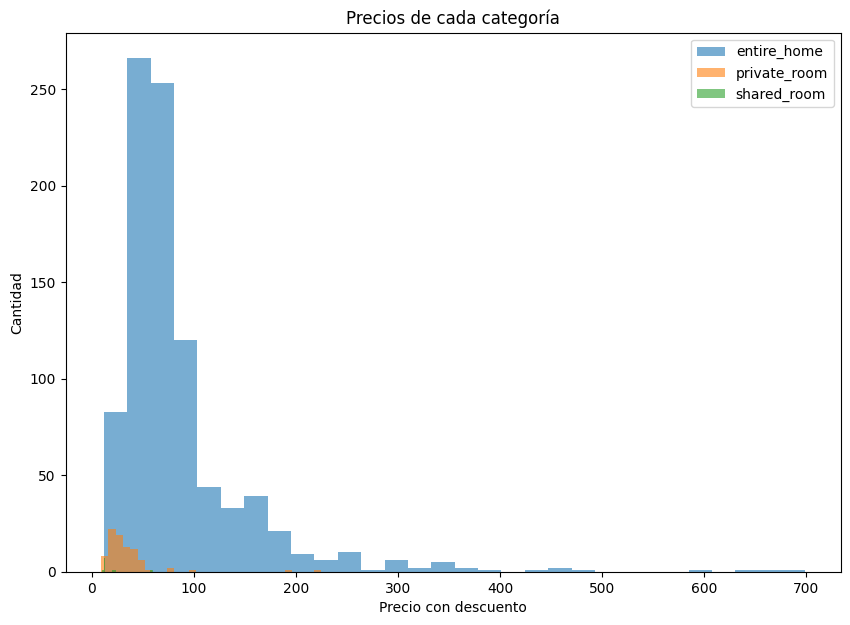

In [ ]:
#Gráfico interactivo transformado a imagen para presentar en GitHub

plt.figure(figsize=(10, 7))

plt.hist(
    categ_entire_home["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.6,
    label="entire_home"
)

plt.hist(
    categ_private_room["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.6,
    label="private_room"
)

plt.hist(
    categ_shared_room["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.6,
    label="shared_room"
)

plt.title("Precios de cada categoría")
plt.xlabel("Precio con descuento")
plt.ylabel("Cantidad")
plt.legend()
plt.show()


#### 4.3.2 Distribución por localidad


In [ ]:
# Tercer gráfico - Distribución de precios por lugar.(gráfico interactivo que no se aprecia en GitHub)
rio_negro_df = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Rio Negro']
san_martin_df = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'San Martin de los Andes']
neuquen_df = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Neuquen']
tierra_del_fuego_df = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Tierra del Fuego']

fig_place_manual = go.Figure()
fig_place_manual.add_trace(go.Histogram(x=rio_negro_df['price_discounted_clean'], name='Rio Negro', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=san_martin_df['price_discounted_clean'], name='San Martin de los Andes', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=neuquen_df['price_discounted_clean'], name='Neuquen', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=tierra_del_fuego_df['price_discounted_clean'], name='Tierra del Fuego', opacity=0.6))

fig_place_manual.update_layout(
    title_text='Distribución de Precios por Lugar',
    xaxis_title='Precio con descuento',
    yaxis_title='Cantidad',
    barmode='overlay'
)
fig_place_manual.show()

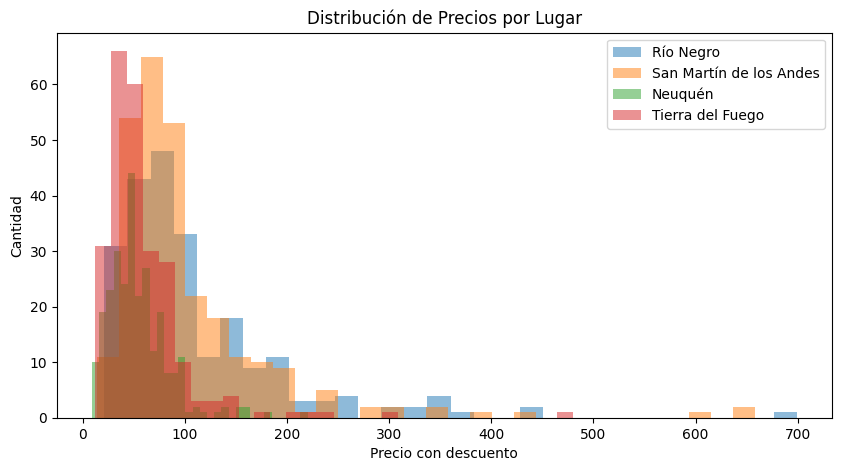

In [ ]:
#Gráfico interactivo transformado a imagen para presentar en GitHub

plt.figure(figsize=(10, 5))

plt.hist(
    rio_negro_df["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.5,
    label="Río Negro"
)

plt.hist(
    san_martin_df["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.5,
    label="San Martín de los Andes"
)

plt.hist(
    neuquen_df["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.5,
    label="Neuquén"
)

plt.hist(
    tierra_del_fuego_df["price_discounted_clean"].dropna(),
    bins=30,
    alpha=0.5,
    label="Tierra del Fuego"
)

plt.title("Distribución de Precios por Lugar")
plt.xlabel("Precio con descuento")
plt.ylabel("Cantidad")
plt.legend()
plt.show()

## 5. Discretización y segmentación de precios


### 5.1 Segmentación mediante intervalos de igual ancho


In [ ]:
etiquetas_categorias_precios=["bajo", "medio", "alto"]

In [ ]:
patag_arg_sindupl3["price_category"]=pd.cut(x=patag_arg_sindupl3["price_original_clean"],bins=3,labels=etiquetas_categorias_precios)

### 5.2 Evaluación de la segmentación inicial


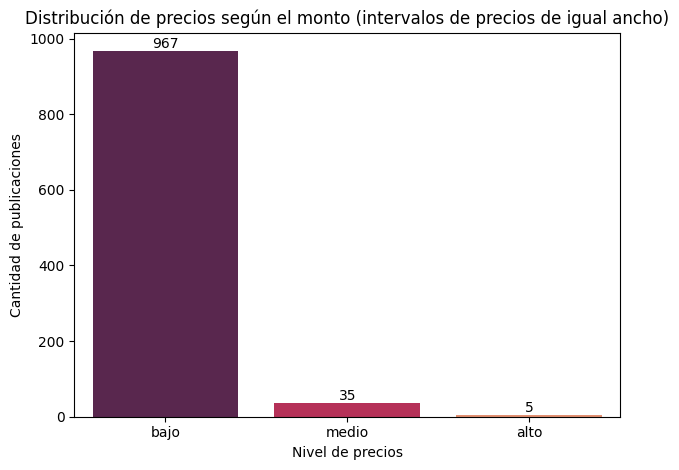

In [ ]:
#Gráfico de barras.
grp_1 = patag_arg_sindupl3.groupby(by="price_category", as_index=False, observed=False).agg(func={'price_original_clean':'count'})
grp_1.columns = ["price_category", "count"]

ax = sns.barplot(x="price_category", y="count", hue="price_category", palette="rocket", data=grp_1)
plt.title("Distribución de precios según el monto (intervalos de precios de igual ancho)")
plt.xlabel("Nivel de precios")
plt.ylabel("Cantidad de publicaciones")
plt.tight_layout()


# Agregamos los montos exactos de publicaciones sobre las barras
for index, row in grp_1.iterrows():
    ax.text(index, row['count'], round(row['count'], 2), color='black', ha="center", va="bottom")

plt.show()

**Interpretación.**

*   La mayor cantidad de las operaciones corresponde a alquileres de la categoría de bajo monto (988 operaciones de bajo monto); mientras que, las categorías de monto medio y alto, ascendieron solamente a 40 operaciones.
*   Los intervalos de igual ancho no parecen adecuados para analizar esa mayor parte de las operaciones que se encuentran concentradas en el primer bin.
*   La primera pregunta que nos surge es: cuánto es el rango en dólares de cada una de esas 3 categorías.
*   La segunda pregunta que nos surge es: cuánto representa el monto total en dólares de cada una de esas 3 categorías en el total de alquileres.
SUPUESTO SIMPLIFICADOR:Si hacemos el supuesto de que todas las publicaciones fueran concretadas y se obtuvieran ingresos por las mismas, haciendo un cálculo global de los ingresos potenciales de cada categoría, tendríamos lo siguiente:

      Intervalos en US$                Monto Total (US$)
    
       
       (8.31, 239]..........................72.401
    
       (239,  469]..........................10.835
    
       (469,  699]....... .................. 3.087







In [ ]:
#Los rangos de los tres bins en dólares, son:
Ancho_bins=pd.cut(x=patag_arg_sindupl3["price_original_clean"],bins=3)

In [ ]:
#Las 40 operaciones de monto medio y alto, representan un 16% del total de ingresos.
Montos_categ_porc=patag_arg_sindupl3.groupby(by="price_category", as_index=False, observed=False).agg(func={'price_original_clean':'sum'})
Montos_categ_porc["porcentaje"]=Montos_categ_porc["price_original_clean"]/(Montos_categ_porc["price_original_clean"].sum())*100
Montos_categ_porc


,price_category,price_original_clean,porcentaje
0,bajo,70726,83.55
1,medio,10835,12.80
2,alto,3087,3.65


### 5.3 Alternativa propuesta: intervalos de igual frecuencia


Se construye `price_category_igualfrec` utilizando cuantiles para obtener segmentos con una distribución más equilibrada de observaciones y comparar su utilidad analítica con los intervalos de igual ancho.


In [ ]:
patag_arg_sindupl3["price_category_igualfrec"]=pd.qcut(x=patag_arg_sindupl3["price_original_clean"], q=3)

### Comparación visual de la segmentación por igual frecuencia


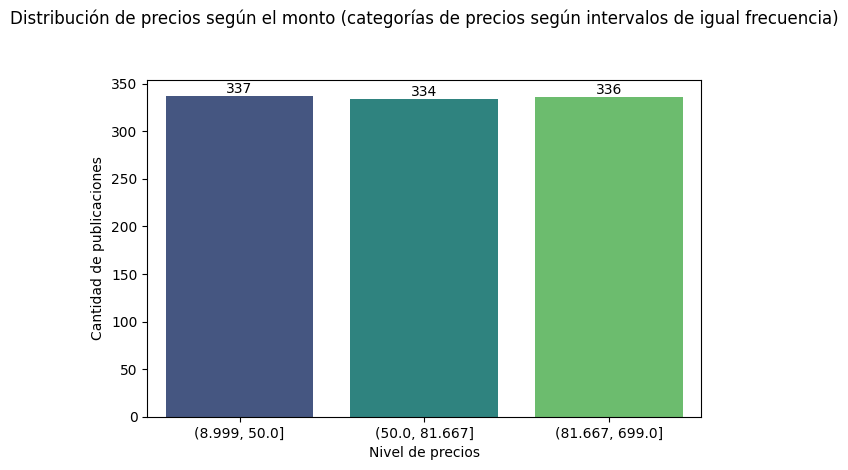

In [ ]:
#Gráfico de barras.
grp_13 = patag_arg_sindupl3.groupby(by="price_category_igualfrec", as_index=False, observed=False).agg(func={'price_original_clean':'count'})
grp_13.columns = ["price_category_igualfrec", "count"]

ax = sns.barplot(x="price_category_igualfrec", y="count", hue="price_category_igualfrec", palette="viridis", data=grp_13, legend=False)
plt.title("Distribución de precios según el monto (categorías de precios según intervalos de igual frecuencia)", pad=40)
plt.xlabel("Nivel de precios")
plt.ylabel("Cantidad de publicaciones")
plt.tight_layout()


# Agregamos los montos exactos de publicaciones sobre las barras
for index, row in grp_13.iterrows():
    ax.text(index, row['count'], round(row['count'], 2), color='black', ha="center", va="bottom")


plt.show()

## 6. Análisis por localidad


### 6.1 Localidades con mayor proporción de calificaciones máximas


In [ ]:
#Rio Negro es la localidad con mayor porcentaje de publicaciones que cumplen con el criterio de best reviews
Agrup_place_bestreviews = patag_arg_sindupl3.groupby(["place"])["best_reviews"].mean() * 100
Agrup_place_bestreviews.head().sort_values(ascending=False)

,best_reviews
place,
Rio Negro,19.47
San Martin de los Andes,17.04
Tierra del Fuego,14.94
Neuquen,11.11


### 6.2 Localidades con mayor cantidad de publicaciones con descuento


In [ ]:
#Tierra del Fuego es la localidad (place) con más publicaciones con descuento.
Agrup_place_discounted = patag_arg_sindupl3.groupby(["place"])["discounted"].sum()
Agrup_place_discounted.head().sort_values(ascending=False)

,discounted
place,
Tierra del Fuego,63
San Martin de los Andes,54
Rio Negro,38
Neuquen,37


### 6.3 Distribución de ratings por localidad


In [ ]:
# histogramas en un mismo par de ejes (gráfico interactivo que no se aprecia en GitHub)
rio_negro_dfb = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Rio Negro']
san_martin_dfb = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'San Martin de los Andes']
neuquen_dfb = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Neuquen']
tierra_del_fuego_dfb = patag_arg_sindupl3[patag_arg_sindupl3['place'] == 'Tierra del Fuego']

fig_place_manual = go.Figure()
fig_place_manual.add_trace(go.Histogram(x=rio_negro_dfb['rating_clean'], name='Rio Negro', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=san_martin_dfb['rating_clean'], name='San Martin de los Andes', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=neuquen_dfb['rating_clean'], name='Neuquen', opacity=0.6))
fig_place_manual.add_trace(go.Histogram(x=tierra_del_fuego_dfb['rating_clean'], name='Tierra del Fuego', opacity=0.6))

fig_place_manual.update_layout(
    title_text='Distribución de Rating por Lugar',
    xaxis_title='Rating',
    yaxis_title='Cantidad',
    barmode='overlay'
)
fig_place_manual.show()

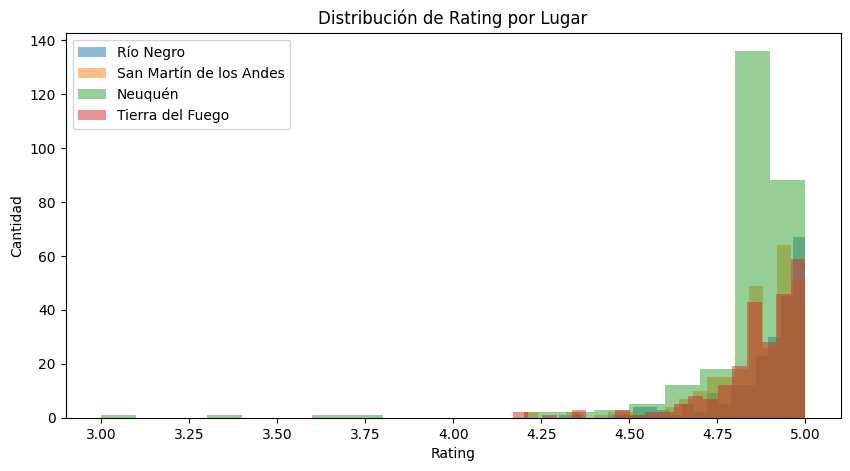

In [ ]:
#Gráfico interactivo transformado a imagen para presentar en GitHub
plt.figure(figsize=(10, 5))

plt.hist(
    rio_negro_dfb["rating_clean"].dropna(),
    bins=20,
    alpha=0.5,
    label="Río Negro"
)

plt.hist(
    san_martin_dfb["rating_clean"].dropna(),
    bins=20,
    alpha=0.5,
    label="San Martín de los Andes"
)

plt.hist(
    neuquen_dfb["rating_clean"].dropna(),
    bins=20,
    alpha=0.5,
    label="Neuquén"
)

plt.hist(
    tierra_del_fuego_dfb["rating_clean"].dropna(),
    bins=20,
    alpha=0.5,
    label="Tierra del Fuego"
)

plt.title("Distribución de Rating por Lugar")
plt.xlabel("Rating")
plt.ylabel("Cantidad")
plt.legend()
plt.show()


### 6.4 Control de consistencia en la variable `city`

Se identifican variantes de una misma ciudad debidas a diferencias de mayúsculas, tildes y escritura. El hallazgo evidencia la necesidad de estandarizar esta variable en la etapa de captura.


In [ ]:
Rio_Negro_city=patag_arg_sindupl3.loc[patag_arg_sindupl3["place"]=="Rio Negro", ["city", "place"]]

In [ ]:
Rio_Negro_city.value_counts()

,,count
city,place,
San Carlos de Bariloche,Rio Negro,164
Villa La Angostura,Rio Negro,21
Dina Huapi,Rio Negro,7
Los Lagos,Rio Negro,4
Villa Traful,Rio Negro,3
Bariloche,Rio Negro,3
La Villa,Rio Negro,3
Puerto Manzano,Rio Negro,2
San Martin de los Andes,Rio Negro,2


In [ ]:
San_Martin_de_los_Andes_city=patag_arg_sindupl3.loc[patag_arg_sindupl3["place"]=="San Martin de los Andes", ["city", "place"]]

In [ ]:
San_Martin_de_los_Andes_city.value_counts()

,,count
city,place,
San Martin de los Andes,San Martin de los Andes,241
San Martín de los Andes,San Martin de los Andes,18
Lácar,San Martin de los Andes,3
San Martín de Los Andes,San Martin de los Andes,2
Neuquén,San Martin de los Andes,1
Lolog,San Martin de los Andes,1
San martin de los Andes,San Martin de los Andes,1
San martin de los andes,San Martin de los Andes,1


In [ ]:
Tierra_del_Fuego_city=patag_arg_sindupl3.loc[patag_arg_sindupl3["place"]=="Tierra del Fuego", ["city", "place"]]

In [ ]:
Tierra_del_Fuego_city.value_counts()

,,count
city,place,
Ushuaia,Tierra del Fuego,213
Río Grande,Tierra del Fuego,9
Tolhuin,Tierra del Fuego,4
Rio Grande,Tierra del Fuego,2
AWF,Tierra del Fuego,2
BAX,Tierra del Fuego,2
AIU,Tierra del Fuego,1
DFF,Tierra del Fuego,1
BMR,Tierra del Fuego,1


In [ ]:
Neuquen_city=patag_arg_sindupl3.loc[patag_arg_sindupl3["place"]=="Neuquen", ["city", "place"]]

In [ ]:
Neuquen_city.value_counts()

,,count
city,place,
Neuquén,Neuquen,215
Cipolletti,Neuquen,28
Plottier,Neuquen,6
Neuquen,Neuquen,5
Confluencia,Neuquen,3
MDJ,Neuquen,2
BVH,Neuquen,1
BGJ,Neuquen,1
KCN,Neuquen,1


## 7. Transformación de datos semiestructurados


### 7.1 Evaluación del formato *tidy* en `characteristics`


La columna `characteristics` contiene múltiples atributos en una sola variable, por lo que no cumple con los principios de datos *tidy*. Se aplican operaciones de manipulación de strings para separar información relevante en columnas independientes y facilitar su análisis.


In [ ]:
patag_arg_sindupl3['characteristics'].head(10)

,characteristics
0,"['1 cama', '1 dormitorio', '1 baño', '1 cama d..."
1,"['1 cama', '1 dormitorio', '1 baño', 'Wifi']"
2,"['1 cama', 'Monoambiente', '1 baño', '1 cama d..."
3,"['2 camas', '1 dormitorio', '1 baño', '1 cama ..."
4,"['1 cama', '1 dormitorio', '1 baño', '1 cama d..."
5,"['2 camas', '1 dormitorio', '1 baño', '1 cama ..."
6,"['2 camas', '1 dormitorio', '1 baño', '1 cama ..."
7,"['2 camas', '1 dormitorio', '1 baño', '1 cama ..."
8,"['1 cama', 'Monoambiente', '1 baño', '1 cama d..."
9,"['1 cama', '2 dormitorios', '1,5 baños compart..."


### 7.2 Extracción de `bathrooms`, `bedrooms` y `beds`


In [ ]:
#Construimos las columnas bathrooms, bedrooms y beds con la cantidad obtenida en la columna characteristics (no eliminamos filas con datos faltantes solamente en estas columnas para no perder información).
# Extraemos la cantidad de Beds y la convertimos a formato float
patag_arg_sindupl3['beds'] = (patag_arg_sindupl3['characteristics'].astype(str).str.extract(r'(\d+(?:[\.,]\d+)?)\s*cama', expand=False)
    .str.replace(',', '.').astype(float))

# Extraemos la cantidad de Bedrooms y la convertimos a formato float
patag_arg_sindupl3['bedrooms'] = (patag_arg_sindupl3['characteristics'].astype(str).str.extract(r'(\d+(?:[\.,]\d+)?)\s*(?:dormitorio|habitaci[oó]n)', expand=False)
    .str.replace(',', '.').astype(float))

# Extraemos los Monoambientes como bedrooms=1
patag_arg_sindupl3.loc[patag_arg_sindupl3['characteristics'].astype(str).str.contains('monoambiente', case=False, na=False), 'bedrooms'] = 1

# Extraemos Bathrooms
patag_arg_sindupl3['bathrooms'] = (patag_arg_sindupl3['characteristics'].astype(str).str.extract(r'(\d+(?:\s*[\.,]\d+)?)\s*baño', expand=False)
    .str.replace(' ', '', regex=False).str.replace(',', '.').astype(float))

# Extraemos los baño de visitas como bathrooms=1
patag_arg_sindupl3.loc[patag_arg_sindupl3['characteristics'].astype(str).str.contains('baño de visitas', case=False, na=False), 'bathrooms'] = 1




## 8. Detección y análisis de outliers


### 8.1 Estandarización del precio


In [ ]:
#Función para estandarizar
def estandarizar_var(x):
    promedio = np.mean(x)
    desvio = np.std(x)
    x_estandarizada = (x-promedio)/(desvio)
    return x_estandarizada

In [ ]:
patag_arg_sindupl3_colum_estandarizada = patag_arg_sindupl3.loc[:,['price_original_clean','price_discounted_clean']].apply(estandarizar_var)

In [ ]:
patag_arg_sindupl3["price_standarized"]=patag_arg_sindupl3_colum_estandarizada["price_original_clean"]

### 8.2 Identificación de valores atípicos y distribución geográfica


In [ ]:
def detectamos_precios_outliers(df_estandarizado, valor_límite, variable):
    precios_outliers = df_estandarizado.loc[np.abs(df_estandarizado[variable])>valor_límite,"price_standarized"].to_list()
    return precios_outliers

In [ ]:
precios_outliers=detectamos_precios_outliers(patag_arg_sindupl3, 3,"price_standarized")

In [ ]:
len(precios_outliers)

22

In [ ]:
Ciudades_con_outliers=patag_arg_sindupl3.loc[patag_arg_sindupl3["price_standarized"].isin(detectamos_precios_outliers(patag_arg_sindupl3, 3,"price_standarized")), ["place", "price_standarized", "price_original_clean", "price_category"]]

### 8.3 Validación de outliers frente a la segmentación de precios


##### Mirando los resultados en general (no por ciudad) y observando en particular la columna generada "price_category", entendemos que el criterio para establecer los bins no es el más adecuado, ya que al crearse bins de igual ancho, la categoría baja incluye la mayor parte de las observaciones.  Nos parece más adecuado para el análisis, haber elegido bins de igual frecuencia (ver columna que agregamos para comparar).  A continuación se presentan dos columnas:

*  en price_category(intervalos de igual ancho;columna solicitada), la mayor parte de los outliers están en la categoría media, cuando en realidad deberían estar en la categoría más alta porque constituyen montos importantes en relación a los precios en general.  
*   creamos una nueva columna calculando la categoría en base a intervalos de igual frecuencia, donde clasifica todos los outliers en la categoría alta.  


In [ ]:
#Calculamos una columna con intervalos de igual frecuencia para compararla con price_category(intervalos de igual ancho).
#Confirmamos que las categorías de los outliers son más razonables con intervalos de igual frecuencia.
Ciudades_con_outliers["igual_frecuencia"]=pd.qcut(x=patag_arg_sindupl3["price_original_clean"],q=3,labels=etiquetas_categorias_precios)


In [ ]:
#La ciudad con más outliers es Rio Negro con 11 outliers, le sigue,
#San Martín de los Andes con 9 outliers,
#y Tierra del Fuego con 2 outliers:
Ciudades_con_outliers.head(30)

,place,price_standarized,price_original_clean,price_category,igual_frecuencia
276,Rio Negro,3.35,325,medio,alto
277,Rio Negro,3.83,360,medio,alto
288,Rio Negro,8.54,699,alto,alto
410,Rio Negro,3.42,330,medio,alto
411,Rio Negro,4.39,400,medio,alto
458,Rio Negro,5.08,450,medio,alto
470,Rio Negro,3.00,300,medio,alto
494,Rio Negro,3.70,350,medio,alto
520,Rio Negro,3.70,350,medio,alto
525,Rio Negro,5.08,450,medio,alto


#### **Observaciones de Outliers en el gráfico Boxplot:**

*   además de presentarse los outliers (de Rio Negro, San Martín de los Andes y Tierra del Fuego) resultantes de los cálculos, el gráfico presenta más outliers, debido a que el Boxplot utiliza un criterio más sensible que el de los cálculos (el boxplot se basa en la regla del 1.5 veces el Rango Intercuartílico (IQR)); o sea que, los outliers por debajo de la línea roja que aparecen en el gráfico no son tan extremos como para superar 3 desviaciones estándar como exige el cálculo.

*   con la misma explicación de la observación anterior, el gráfico también presenta outliers en Neuquen que no superan las 3 desviaciones standard.

*   vale aclarar que algunos outliers tienen el mismo monto, por lo tanto, la cantidad de círculos que representan los outliers en el gráfico es menor a la cantidad de observaciones según los cálculos (por ejemplo, los 2 outliers de US$ 350 en San Martín de los Andes se representan con un sólo círculo; esto hace que, en lugar de mostrarse 9 outliers sobre la línea de 3 desviaciones standard, en realidad, se presenten 8 círculos).

*   si tenemos en cuenta las medianas que calculamos a continuación del boxplot, las mismas se presentan razonables ya que son similares en Rio Negro(84.5) y San Martín de los Andes(82) y por otro lado, las de Tierra del Fuego(53) y Neuquen(51) están significativamente por debajo.








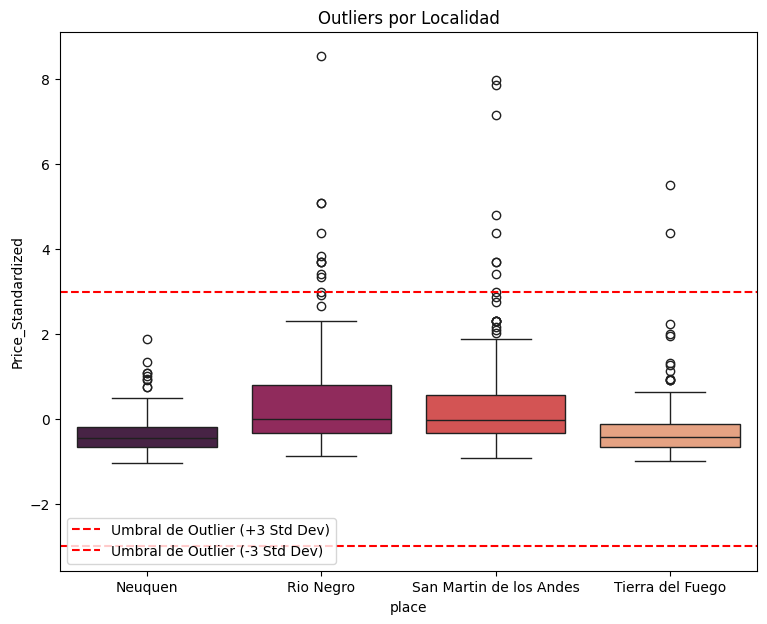

In [ ]:
#Boxplot que presenta los outliers en Rio Negro y San Martín de los Andes
plt.figure(figsize=(9, 7))
sns.boxplot(x=patag_arg_sindupl3['place'], y=patag_arg_sindupl3['price_standarized'], hue=patag_arg_sindupl3['place'], palette= "rocket")
plt.title("Outliers por Localidad")
plt.ylabel("Price_Standardized")
plt.axhline(y=3, color='r', linestyle='--', label='Umbral de Outlier (+3 Std Dev)')
plt.axhline(y=-3, color='r', linestyle='--', label='Umbral de Outlier (-3 Std Dev)')
plt.legend()
plt.show()


### Medianas de precios estandarizados y originales


In [ ]:
patag_arg_sindupl3.groupby('place')['price_standarized'].median()

,price_standarized
place,
Neuquen,-0.46
Rio Negro,0.01
San Martin de los Andes,-0.03
Tierra del Fuego,-0.43


In [ ]:
patag_arg_sindupl3.groupby('place')['price_original_clean'].median()

,price_original_clean
place,
Neuquen,51.00
Rio Negro,84.50
San Martin de los Andes,82.00
Tierra del Fuego,53.00


## 9. Enriquecimiento mediante API externa


### 9.1 Incorporación de horarios de amanecer y atardecer


Para realizar solicitudes a esta API, debimos importar, además: "requests", "time" y "functools".

*   "requests" es un módulo que se utiliza en Python para realizar solicitudes HTTP a servidores externos (como la API Sunrise-Sunset).  Nos permite enviar y recibir datos de sitios web y es importante para interactuar con APIs y obtener información de fuentes externas en el código Python.

*   "time" es un módulo de Python que acá, nos sirve para dos cosas:
1.   algunas APIs tienen restricciones sobre cuantas solicitudes realizar en un período de tiempo que si se superan, la API bloquea las solicitudes y da errores. time.sleep(delay) pausa la ejecución de esa restricción por un tiempo y esto, permite hacer las solicitudes si superamos el límite.
2.   permite reintentar después de un tiempo cuando da errores temporales de red o de servicio sin recargar el servidor de la API (esto se llama "backoff exponencial").

*   "functools" es un módulo que en Python se utiliza para trabajar con funciones de orden superior, es decir, funciones que toman otras funciones como argumentos o devuelven funciones como resultado. La función functools.lru_cache (Least Recently Used Cache)es un decorador que se aplica a otras funciones para "cachear" (almacenar en memoria) sus resultados. Cuando una función decorada con lru_cache es llamada con los mismos argumentos, en lugar de ejecutar todo el código de la función, devuelve el resultado que ya calculó y almacenó previamente. Esto sirve para:
1.   evitar llamadas a la API repetidas veces con los mismos parámetros, lo que puede acelerar significativamente el proceso.
2.   reducir la carga en el servidor de la API.






In [ ]:
import requests
import time
import functools

# Usa un caché para almacenar los resultados de la API para evitar solicitudes repetidas
@functools.lru_cache(maxsize=1024)
def get_sunrise_sunset_cached(lat, lng, date_str):
    url = f"https://api.sunrise-sunset.org/json?lat={lat}&lng={lng}&date={date_str}&formatted=0"

    retries = 5  # Número máximo de reintentos
    delay = 1    # Retraso inicial en segundos

    for i in range(retries):
        try:
            response = requests.get(url)
            response.raise_for_status() # Lanza una excepción para errores HTTP (4xx o 5xx)
            data = response.json()
            if data['status'] == 'OK':
                return data['results']['sunrise'], data['results']['sunset']
            else:
                # Si hay un error de la API que no sea 429, no reintentar
                if response.status_code != 429:
                    # print(f"API error (no 429) para (lat={lat}, lng={lng}, date={date_str}): {data['status']}") # Suprimido
                    return None, None

                # Si es un error 429, reintentar después del retraso
                # print(f"Reintentando (intento {i+1}/{retries}) para (lat={lat}, lng={lng}, date={date_str}) debido a: {response.status_code}") # Suprimido
                time.sleep(delay)  # Espera antes de reintentar
                delay *= 2         # Aumenta el retraso exponencialmente

        except requests.exceptions.RequestException as e:
            # print(f"Solicitud fallida (intento {i+1}/{retries}) para (lat={lat}, lng={lng}, date={date_str}): {e}") # Suprimido
            time.sleep(delay)      # Espera antes de reintentar
            delay *= 2             # Aumenta el retraso exponencialmente

    print(f"Fallo la solicitud después de {retries} reintentos para (lat={lat}, lng={lng}, date={date_str})")
    return None, None # Devuelve None si falla después de todos los reintentos

def get_sunrise_sunset(row):
    lat = row['latitude']
    lng = row['longitude']
    date_str = row['check_in'].strftime('%Y-%m-%d')
    housing_id = int(row['id_alojamiento']) if pd.notnull(row['id_alojamiento']) else 'N/A'

    # Llama a la función cacheada
    sunrise, sunset = get_sunrise_sunset_cached(lat, lng, date_str)

    if sunrise is None and sunset is None:
        print(f"No se pudieron obtener datos de amanecer/atardecer para ID {housing_id} (lat={lat}, lng={lng}, date={date_str})")

    return pd.Series({'sunrise': sunrise, 'sunset': sunset})

In [ ]:
# Aplicamos la función a nuestro dataframe y creamos las nuevas columnas.
# Creamos una copia para evitar errores
patag_arg_sindupl3_enriched = patag_arg_sindupl3.copy()

patag_arg_sindupl3_enriched[['sunrise', 'sunset']] = patag_arg_sindupl3_enriched.apply(get_sunrise_sunset, axis=1)



In [ ]:
# Creamos 2 nuevas columnas para transformar la información a hora local de Argentina

import pytz

# Convertir las columnas 'sunrise' y 'sunset' a datetime con timezone UTC
patag_arg_sindupl3_enriched['sunrise_utc'] = pd.to_datetime(patag_arg_sindupl3_enriched['sunrise'], errors='coerce')
patag_arg_sindupl3_enriched['sunset_utc'] = pd.to_datetime(patag_arg_sindupl3_enriched['sunset'], errors='coerce')

# Definir la zona horaria local de Argentina
local_timezone = pytz.timezone('America/Argentina/Buenos_Aires')

# Convertir las horas UTC a la hora local de Argentina
patag_arg_sindupl3_enriched['sunrise_local'] = patag_arg_sindupl3_enriched['sunrise_utc'].dt.tz_convert(local_timezone)
patag_arg_sindupl3_enriched['sunset_local'] = patag_arg_sindupl3_enriched['sunset_utc'].dt.tz_convert(local_timezone)

# Mostrar las primeras filas con las nuevas columnas de hora local
display(patag_arg_sindupl3_enriched[['id_alojamiento', 'place', 'check_in', 'sunrise_utc', 'sunrise_local', 'sunset_utc', 'sunset_local']].head())

,id_alojamiento,place,check_in,sunrise_utc,sunrise_local,sunset_utc,sunset_local
0,42980235.00,Neuquen,2023-07-01,2023-07-01 11:50:15+00:00,2023-07-01 08:50:15-03:00,2023-07-01 21:21:58+00:00,2023-07-01 18:21:58-03:00
1,910778141360333952.00,Neuquen,2023-08-01,2023-08-01 11:33:13+00:00,2023-08-01 08:33:13-03:00,2023-08-01 21:44:00+00:00,2023-08-01 18:44:00-03:00
2,50265327.00,Neuquen,2023-07-01,2023-07-01 11:50:14+00:00,2023-07-01 08:50:14-03:00,2023-07-01 21:21:55+00:00,2023-07-01 18:21:55-03:00
3,716439197957115008.00,Neuquen,2023-07-01,2023-07-01 11:50:15+00:00,2023-07-01 08:50:15-03:00,2023-07-01 21:22:00+00:00,2023-07-01 18:22:00-03:00
4,12904217.00,Neuquen,2023-07-02,2023-07-02 11:50:08+00:00,2023-07-02 08:50:08-03:00,2023-07-02 21:22:25+00:00,2023-07-02 18:22:25-03:00


## 10. Relación entre precio y características del alojamiento


### 10.1 Precio promedio según cantidad de baños, dormitorios y camas


In [ ]:
patag_arg_sindupl3.groupby('bathrooms').agg({'price_original_clean': 'mean'})

,price_original_clean
bathrooms,
0.00,53.00
1.00,65.89
1.50,74.91
2.00,128.90
2.50,175.28
3.00,239.95
3.50,286.14
4.00,241.33
4.50,350.00


In [ ]:
patag_arg_sindupl3.groupby('bedrooms').agg({'price_original_clean': 'mean'})

,price_original_clean
bedrooms,
1.00,61.43
2.00,100.61
3.00,159.67
4.00,256.75
5.00,265.67
6.00,462.50


In [ ]:
patag_arg_sindupl3.groupby('beds').agg({'price_original_clean': 'mean'})

,price_original_clean
beds,
1.00,58.39
2.00,63.48
3.00,80.44
4.00,102.75
5.00,157.95
6.00,161.09
7.00,201.83
8.00,227.80
10.00,383.33


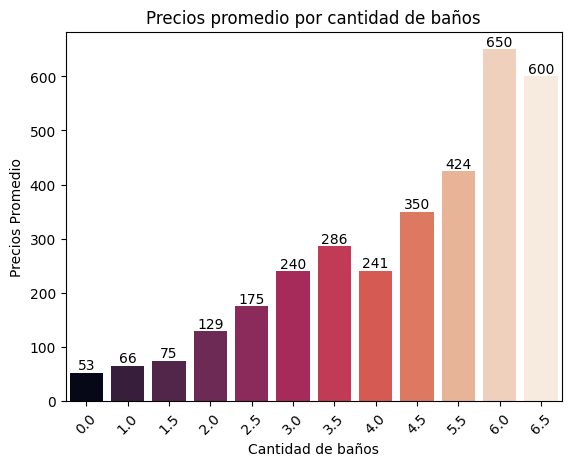

In [ ]:
#Gráfico de barras.
grp_10 = patag_arg_sindupl3.groupby(by='bathrooms', as_index=False, observed=False).agg(func={'price_original_clean':'mean'})
grp_10.columns = ["bathrooms", "precio_promedio"]
ax = sns.barplot(x="bathrooms", y="precio_promedio", hue="bathrooms", palette="rocket", data=grp_10, legend=False)
plt.title("Precios promedio por cantidad de baños")
plt.xlabel("Cantidad de baños")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)

# Agregamos los montos exactos de publicaciones sobre las barras
for index, row in grp_10.iterrows():
    ax.text(index, row['precio_promedio'], round(row['precio_promedio']), color='black', ha="center", va="bottom")

plt.show()

**Interpretación.**
La tendencia es que los precios aumenten al aumentar la cantidad de baños. Sin embargo, hay dos casos (con 4 y 6 baños) donde la relación cambia con respecto a los otros casos.
El precio promedio para 6 baños sólamente se compone de una casa lujosa en San Martin de los Andes, con piscina, frente al lago, con 6 dormitorios, etc.
El precio promedio para 4 baños podría tener errores ya que incluye 2 alojamientos con precios demasiado bajos que se deberían investigar.
El precio promedio para 0 baños corresponde a un alojamiento (id_alojamiento=32223913.00) que también podría investigarse, pero no es significativo para el análisis.



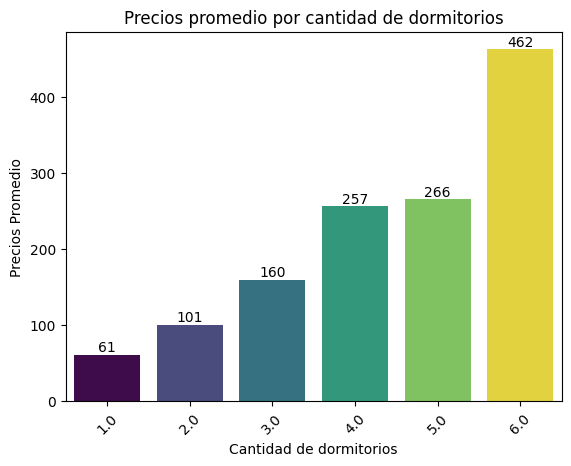

In [ ]:
grp_11 = patag_arg_sindupl3.groupby(by='bedrooms', as_index=False, observed=False).agg(func={'price_original_clean':'mean'})
grp_11.columns = ["bedrooms", "precio_promedio"]
ax = sns.barplot(x="bedrooms", y="precio_promedio", hue="bedrooms", palette="viridis", data=grp_11, legend=False)
plt.title("Precios promedio por cantidad de dormitorios")
plt.xlabel("Cantidad de dormitorios")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)

# Agregamos los montos exactos de publicaciones sobre las barras
for index, row in grp_11.iterrows():
    ax.text(index, row['precio_promedio'], round(row['precio_promedio']), color='black', ha="center", va="bottom")

plt.show()


**Interpretación.**
La tendencia es que los precios aumenten al aumentar la cantidad de dormitorios. Sin embargo en el caso de 6 dormitorios, el precio tiene un aumento mas significativo.
El precio promedio para 6 dormitorios incluye 4 alojamientos, de los cuales 2 de ellos tienen un precio muy alto por corresponder a casas muy grandes y lujosas.
El precio promedio para 4 y 5 dormitorios no tiene una gran variación.
Los Monoambientes están incluídos en los alojamientos de 1 dormitorio.



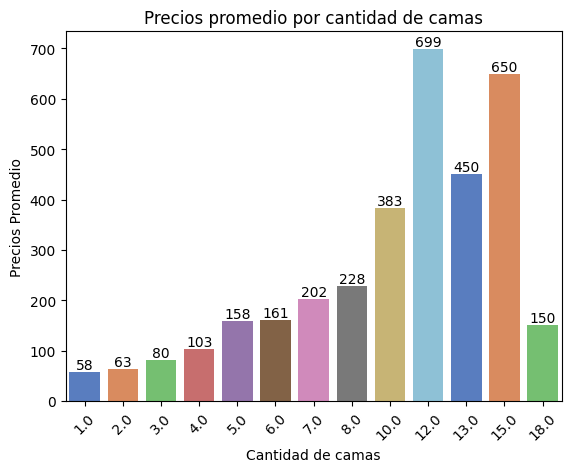

In [ ]:
grp_12 = patag_arg_sindupl3.groupby(by='beds', as_index=False, observed=False).agg(func={'price_original_clean':'mean'})
grp_12.columns = ["beds", "precio_promedio"]
ax = sns.barplot(x="beds", y="precio_promedio", hue="beds", palette="muted", data=grp_12, legend=False)
plt.title("Precios promedio por cantidad de camas")
plt.xlabel("Cantidad de camas")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)

# Agregamos los montos exactos de publicaciones sobre las barras
for index, row in grp_12.iterrows():
    ax.text(index, row['precio_promedio'], round(row['precio_promedio']), color='black', ha="center", va="bottom")

plt.show()


**Interpretación.**
La tendencia es que los precios aumenten al aumentar la cantidad de camas. Sin embargo, el caso de 18 camas corresponde a un solo alojamiento atípico (una cabaña para muchas personas) donde el precio es significativamente menor.
El precio promedio para 12 camas está compuesto por una sola casa de lujo con amenities como golf, polo, esquí, etc. Lo cual explica el valor por encima de todos los promedios.
El precio promedio para 15 camas constituye una sola casa lujosa con piscina frente al lago(misma casa que en el gráfico de baños se despegaba bastante su valor).



### 10.2 Correlación de Pearson entre precio y características


Para estimar correctamente la correlación de Pearson, se trabaja con pares de variables sin valores faltantes. Se calcula la asociación lineal entre `price_original_clean` y `beds`, `bedrooms` y `bathrooms` de forma independiente.


In [ ]:
correl_beds = patag_arg_sindupl3[["price_original_clean","beds"]].dropna()
r_beds,p_beds=pearsonr(correl_beds["price_original_clean"], correl_beds["beds"])
print(r_beds)
print(p_beds)


0.5935814537666606
2.0019372232660214e-96


In [ ]:
correl_bedrooms = patag_arg_sindupl3[["price_original_clean","bedrooms"]].dropna()
r_bedrooms,p_bedrooms=pearsonr(correl_bedrooms["price_original_clean"], correl_bedrooms["bedrooms"])
print(r_bedrooms)
print(p_bedrooms)


0.6325330720511783
2.6246558230614937e-111


In [ ]:
correl_bathrooms = patag_arg_sindupl3[["price_original_clean","bathrooms"]].dropna()
r_bathrooms,p_bathrooms=pearsonr(correl_bathrooms["price_original_clean"], correl_bathrooms["bathrooms"])
print(r_bathrooms)
print(p_bathrooms)


0.666952347907359
5.152624248497465e-128


### Preparación de datos para visualización de correlaciones


In [ ]:
#Transformamos el dataset de formato wide a formato long:
pivot1=pd.melt(patag_arg_sindupl3, id_vars=['id_alojamiento', 'name', 'category', 'rating', 'city', 'latitude',
       'longitude', 'characteristics', 'check_in', 'check_out',
       'price_discounted', 'price_original', 'place', 'rating_clean',
       'best_reviews', 'price_original_clean', 'discounted',
       'price_discounted_clean', 'price_category'],value_vars=["beds", "bedrooms", "bathrooms"],var_name="comodidades", value_name="cantidades")

**Observaciones del gráfico de correlación entre los precios y la cantidad de baños, camas y dormitorios:**

*   Los precios tienen un aumento más importante que lo que aumenta la cantidad de baños.

*   Los precios aumentan menos que la cantidad de camas.

*   El aumento en los precios se muestra más moderado cuando aumenta la cantidad de dormitorios que cuando aumentan los baños; por el contrario, el aumento de precios es mayor cuando aumentan los dormitorios que cuando se agregan camas.



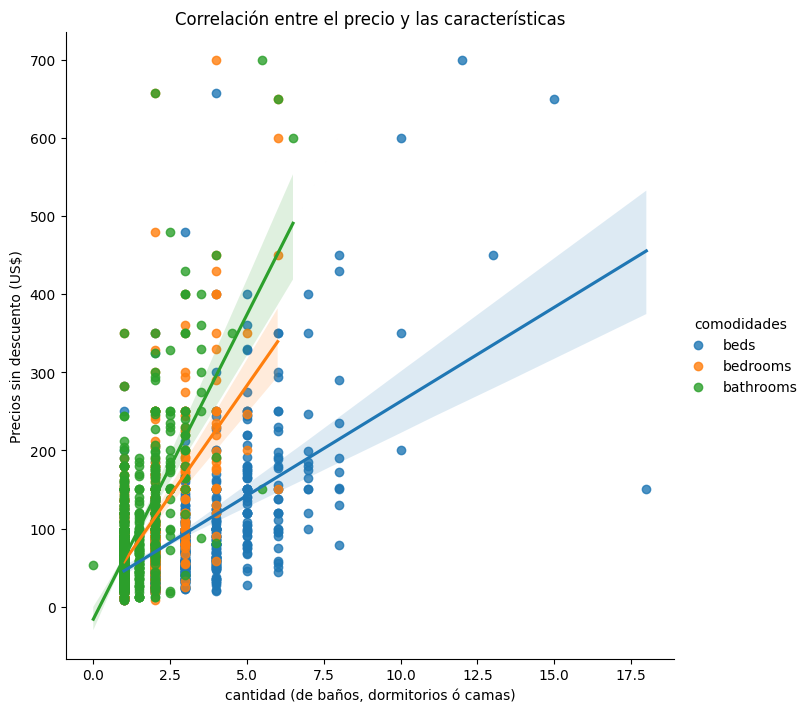

In [ ]:
#Gráfico de la relación entre las variables
g = sns.lmplot(data=pivot1, x="cantidades", y="price_original_clean", hue="comodidades", height=7)
g.set_axis_labels("cantidad (de baños, dormitorios ó camas)", "Precios sin descuento (US$)")
plt.title("Correlación entre el precio y las características")
plt.show()

## Competencias demostradas

`Data Cleaning` · `Data Quality` · `Data Transformation` · `Feature Engineering` · `Missing Data` · `Duplicate Detection` · `Outlier Analysis` · `Data Validation` · `API Integration` · `Exploratory Data Analysis` · `Python` · `Pandas`

> **Enfoque del proyecto:** transformar datos imperfectos en información consistente, documentando cada decisión y evitando eliminar información sin una validación previa.


# Conclusiones y aprendizajes del proyecto


## Principales problemas de calidad detectados


El proceso de calidad de datos permitió identificar tres tipos principales de problemas:

- **Duplicados exactos y potenciales:** se eliminaron 73 registros después de aplicar reglas de comparación sobre múltiples atributos. Los casos ambiguos se conservaron para evitar eliminar observaciones válidas.
- **Identificadores inconsistentes:** `id_alojamiento` no funciona de manera completamente confiable como clave única; aparecen IDs repetidos para registros diferentes y registros aparentemente equivalentes con IDs distintos.
- **Datos semiestructurados e inconsistencias de formato:** `characteristics` concentra varios atributos en texto libre; `city` presenta variantes de escritura; ratings y precios requieren conversión antes del análisis.
- **Valores faltantes:** se trataron según la naturaleza de cada variable. Para `rating` se comparó la imputación por media con una alternativa basada en mediana por localidad y categoría.

Estos hallazgos muestran que la mayor dificultad del proyecto no está en una transformación aislada, sino en **definir reglas de calidad que distingan errores reales de observaciones legítimamente similares**.


## Recomendaciones para mejorar la calidad en origen

1. Utilizar `id_alojamiento` como identificador único y aplicar restricciones de integridad para evitar reutilizaciones inconsistentes.
2. Estandarizar `city`, `category` y otros campos categóricos mediante listas controladas o catálogos maestros.
3. Reemplazar la columna de texto libre `characteristics` por variables separadas (`beds`, `bedrooms`, `bathrooms`, wifi, calefacción, etc.).
4. Almacenar ratings y precios directamente en tipos numéricos, evitando símbolos o formatos que requieran limpieza posterior.
5. Definir un criterio único para latitud y longitud y aplicar validaciones geográficas en la captura.

Estas medidas reducirían el costo de preparación de datos y mejorarían la trazabilidad, consistencia y reutilización del dataset.


## Dataset final


### Síntesis analítica

El dataset final pasa de **1.080 a 1.007 registros** y de **12 a 26 variables**. Además de la limpieza, el proyecto incorpora variables derivadas de ratings, descuentos, precios, características del alojamiento y datos externos de amanecer/atardecer.

Entre los principales aprendizajes analíticos se observa que:

- La segmentación de precios mediante **intervalos de igual ancho** concentra excesivamente las observaciones en la categoría baja; para este dataset, los **intervalos de igual frecuencia** ofrecen una comparación más equilibrada.
- Los precios presentan valores atípicos que requieren interpretación contextual y no deberían eliminarse automáticamente.
- Entre las características analizadas, la cantidad de **baños** presenta la asociación lineal positiva más fuerte con el precio (`r ≈ 0,67`), seguida por dormitorios y camas. Esta relación es descriptiva y no implica causalidad.
- La calidad del análisis depende de mejorar la estandarización de identificadores, ciudades y características desde el momento de captura.

### Resultado

El proyecto entrega un dataset más consistente y analíticamente utilizable, junto con un proceso documentado de decisiones de limpieza y validación. Más que aplicar transformaciones mecánicas, el trabajo demuestra la importancia de **investigar anomalías, justificar criterios y conservar la trazabilidad de las decisiones de Data Wrangling**.


## Resultado del proceso de transformación


### Diccionario de variables generadas


## Qué demuestra este proyecto

Este proyecto muestra un flujo de **Data Wrangling end-to-end**: integración de fuentes, diagnóstico de calidad, definición de reglas de deduplicación, tratamiento de faltantes, estandarización de variables, ingeniería de características, análisis de outliers y enriquecimiento mediante API.

El foco no está únicamente en ejecutar transformaciones con Pandas, sino en **justificar las decisiones tomadas y preservar la trazabilidad entre los datos originales y las variables procesadas**. Esto deja un dataset final más consistente y preparado para análisis exploratorio o etapas posteriores de modelado.

**Tecnologías:** Python · Pandas · NumPy · SciPy · Matplotlib · Seaborn · Plotly · Requests · REST API